### APS1070 Project 3 - Part 1, Git Practice

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   **Name**: Emad Abdul Malik Shattari
*   **Student ID**: 1012843924



## Part 1: Getting started with GitHub [1.5 Marks + 2 Mark Git Submission]


For the first four parts (Part 1-4) of this project, we will work on a [population of countries dataset](https://ourworldindata.org/grapher/population) which reports the population of over 200 countries worldwide from 10000 BCE to 2023. Download the dataset in .csv format using the provided code below. Using the Pandas package, create a population dataframe with only the countries provided in [this GitHub list](https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt) (237 countries - you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns. Then, remove all the countries that have at least missing or invalid value over the years.

In [1]:
import pandas as pd
import requests, io

headers = {"User-Agent": "Mozilla/5.0"}
raw_data = pd.read_csv(
    filepath_or_buffer=io.StringIO(requests.get(
        'https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=true',
        headers=headers).text),
    index_col=False)

countries_list_url = "https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt"

In [2]:
# 'raw_data'
print(f"shape of 'raw_data': {raw_data.shape}")
print(f"columns in 'raw_data': {raw_data.columns.tolist()}")
print("\nfirst 7 rows of 'raw_data':")
raw_data.head(7)

shape of 'raw_data': (58824, 4)
columns in 'raw_data': ['entity', 'code', 'year', 'population_historical']

first 7 rows of 'raw_data':


,entity,code,year,population_historical
0,Afghanistan,AFG,-10000,14737
1,Afghanistan,AFG,-9000,20405
2,Afghanistan,AFG,-8000,28253
3,Afghanistan,AFG,-7000,39120
4,Afghanistan,AFG,-6000,54166
5,Afghanistan,AFG,-5000,75000
6,Afghanistan,AFG,-4000,306250


In [3]:
# list of countries
countries_txt = requests.get(countries_list_url, headers=headers).text
countries_list = [c.strip() for c in countries_txt.splitlines() if c.strip()]

# years of interest: [1901, 2023] (123 years)
years = list(range(1901, 2024))

# step 1: population dataframe with 237 countries and 123 years [1901, 2023]

# rows that belong to 237 countries and 123 years [1901, 2023]
filtered = raw_data[raw_data['entity'].isin(countries_list) & raw_data['year'].isin(years)]

# population dataframe with 237 countries as rows and 123 years [1901, 2023] as columns
population = filtered.pivot_table(index='entity', columns='year', values='population_historical')
population.index.name = "Country"
population.columns.name = "Year"

# step 2: remove countries with missing or invalid values over 123 years [1901, 2023]

population = population.reindex(columns=years)

valid_countries = population.notna().all(axis=1) & (population > 0).all(axis=1)
population = population[valid_countries]

print(f"total number of countries in provided list: {len(countries_list)}")
print(f"number of countries removed from population dataset: {len(countries_list) - population.shape[0]}")
print(f"number of countries present in updated population dataset: {population.shape[0]}")
print(f"number of years in updated population dataset: {population.shape[1]}")

print("\nfirst 7 rows of updated population dataset:")
population.head(7)

total number of countries in provided list: 237
number of countries removed from population dataset: 41
number of countries present in updated population dataset: 196
number of years in updated population dataset: 123

first 7 rows of updated population dataset:


Year,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,4751177.0,4802500.0,4861833.0,4921891.0,4982681.0,5044212.0,5106495.0,5169536.0,5300178.0,5504191.0,...,32792528.0,33831767.0,34700613.0,35688941.0,36743040.0,37856125.0,39068977.0,40000410.0,40578847.0,41454762.0
Albania,813539.0,821036.0,828461.0,835954.0,843514.0,851143.0,858841.0,866609.0,874016.0,881057.0,...,2903748.0,2898634.0,2897868.0,2898245.0,2894229.0,2885011.0,2871950.0,2849641.0,2827614.0,2811660.0
Algeria,4787149.0,4859600.0,4939332.0,5020372.0,5102742.0,5186463.0,5271557.0,5358048.0,5433528.0,5497750.0,...,39205035.0,40019528.0,40850719.0,41689302.0,42505033.0,43294551.0,44042094.0,44761099.0,45477391.0,46164222.0
Andorra,4551.0,4581.0,4610.0,4640.0,4670.0,4700.0,4730.0,4761.0,4802.0,4855.0,...,73755.0,72195.0,72197.0,73780.0,75181.0,76492.0,77397.0,78379.0,79722.0,80869.0
Angola,3083888.0,3064493.0,3043335.0,3022320.0,3001447.0,2980714.0,2960121.0,2939666.0,2921666.0,2906100.0,...,27160767.0,28157802.0,29183072.0,30234836.0,31297160.0,32375633.0,33451139.0,34532427.0,35635028.0,36749909.0
Antigua and Barbuda,34307.0,34017.0,33707.0,33399.0,33095.0,32793.0,32493.0,32197.0,31919.0,31659.0,...,88784.0,89421.0,89980.0,90483.0,90942.0,91377.0,91864.0,92358.0,92850.0,93331.0
Argentina,4855502.0,5036658.0,5229108.0,5428911.0,5636349.0,5851713.0,6075305.0,6307441.0,6532092.0,6748544.0,...,43024071.0,43477011.0,43900312.0,44288898.0,44654876.0,44973469.0,45191960.0,45312282.0,45407904.0,45538402.0


1. Write a function to do the following: **[0.5]**
    * Takes the dataframe, and your list of countries/regions as inputs (Afghanistan, Albania, Algeria, ...)
    * Plots time-series for the input list (it is best to plot each country in a separate graph (subplot), so you can easily compare them.)
    
2. Apply `StandardScalar` to the data. Each year should have a `mean` of zero and a `StD` of 1. **[0.25]**
3. Pick two countries whose names are closest to your first name using string edit distance.
Hint: you can use `Levenshtein.distance()` from the python-Levenshtein package. You may find [this link](https://www.geeksforgeeks.org/python/introduction-to-python-levenshtein-module/) helpful.
4. Run the function in `step 1` on both the original as well as the standardized dataset for the two countries you picked in `step 3` plus `Japan`, `Bosnia and Herzegovina`, `Latvia`, and `United Arab Emirates`. (If you have already selected one of these countries, go down the list and pick the next one you haven't selected) **[0.25]**
5. Discuss the trends in the standardized time-series for all these countries. What does it mean if the curve goes up or down? What does the sign of values indicate? **[0.5]**

,Mean,Standard Deviation
Year,,
1901,0.0,1.0
1902,-0.0,1.0
1903,-0.0,1.0
1904,0.0,1.0
1905,-0.0,1.0
...,...,...
2019,-0.0,1.0
2020,0.0,1.0
2021,0.0,1.0


countries ranked by 'Levenshtein Distance' from 'EMAD'


,Country,Levenshtein Distance
0,Chad,2
1,Oman,2
2,Iran,3
3,Iraq,3
4,Mali,3
...,...,...
191,Saint Kitts and Nevis,19
192,Bosnia and Herzegovina,20
193,Central African Republic,22
194,Democratic Republic of Congo,25


two closest country names to 'EMAD': ['Chad', 'Oman']

countries input list for 'plot_ts()': ['Chad', 'Oman', 'Japan', 'Bosnia and Herzegovina', 'Latvia', 'United Arab Emirates']


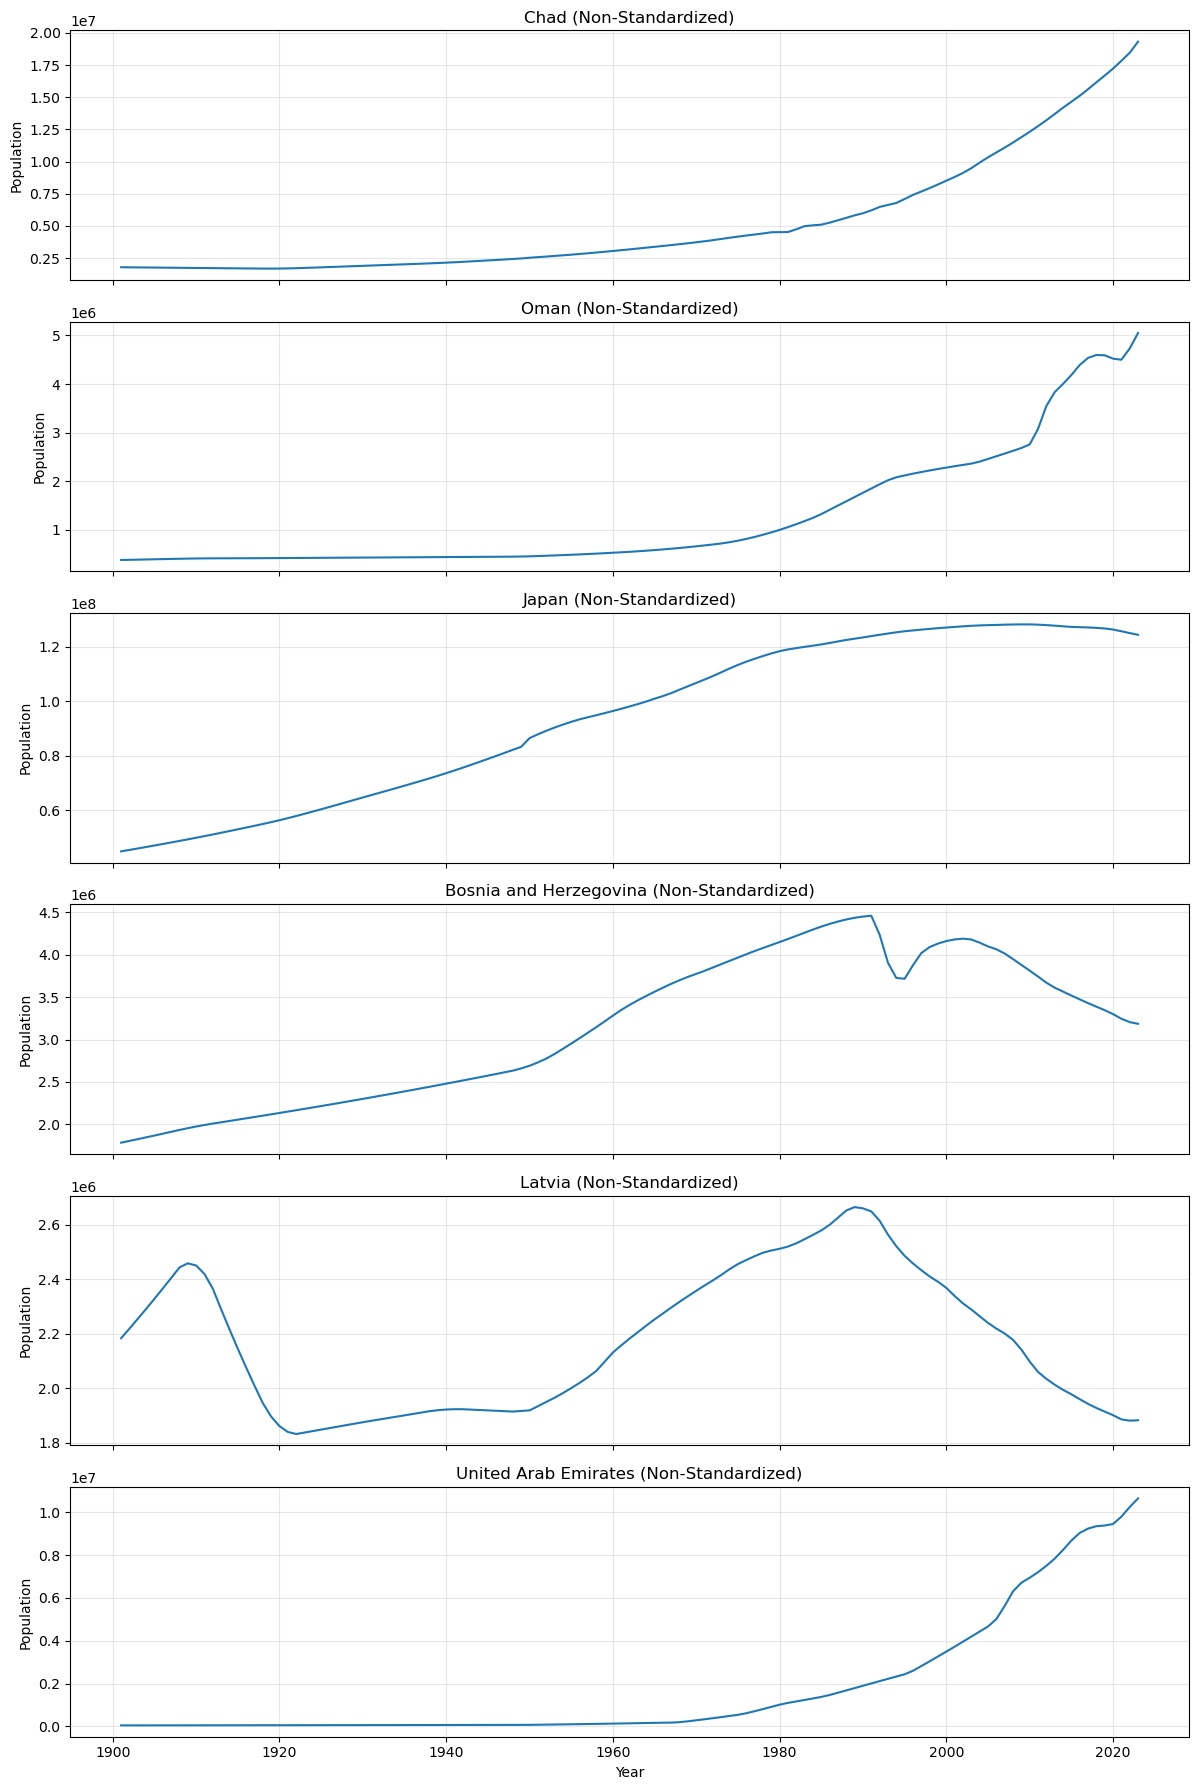

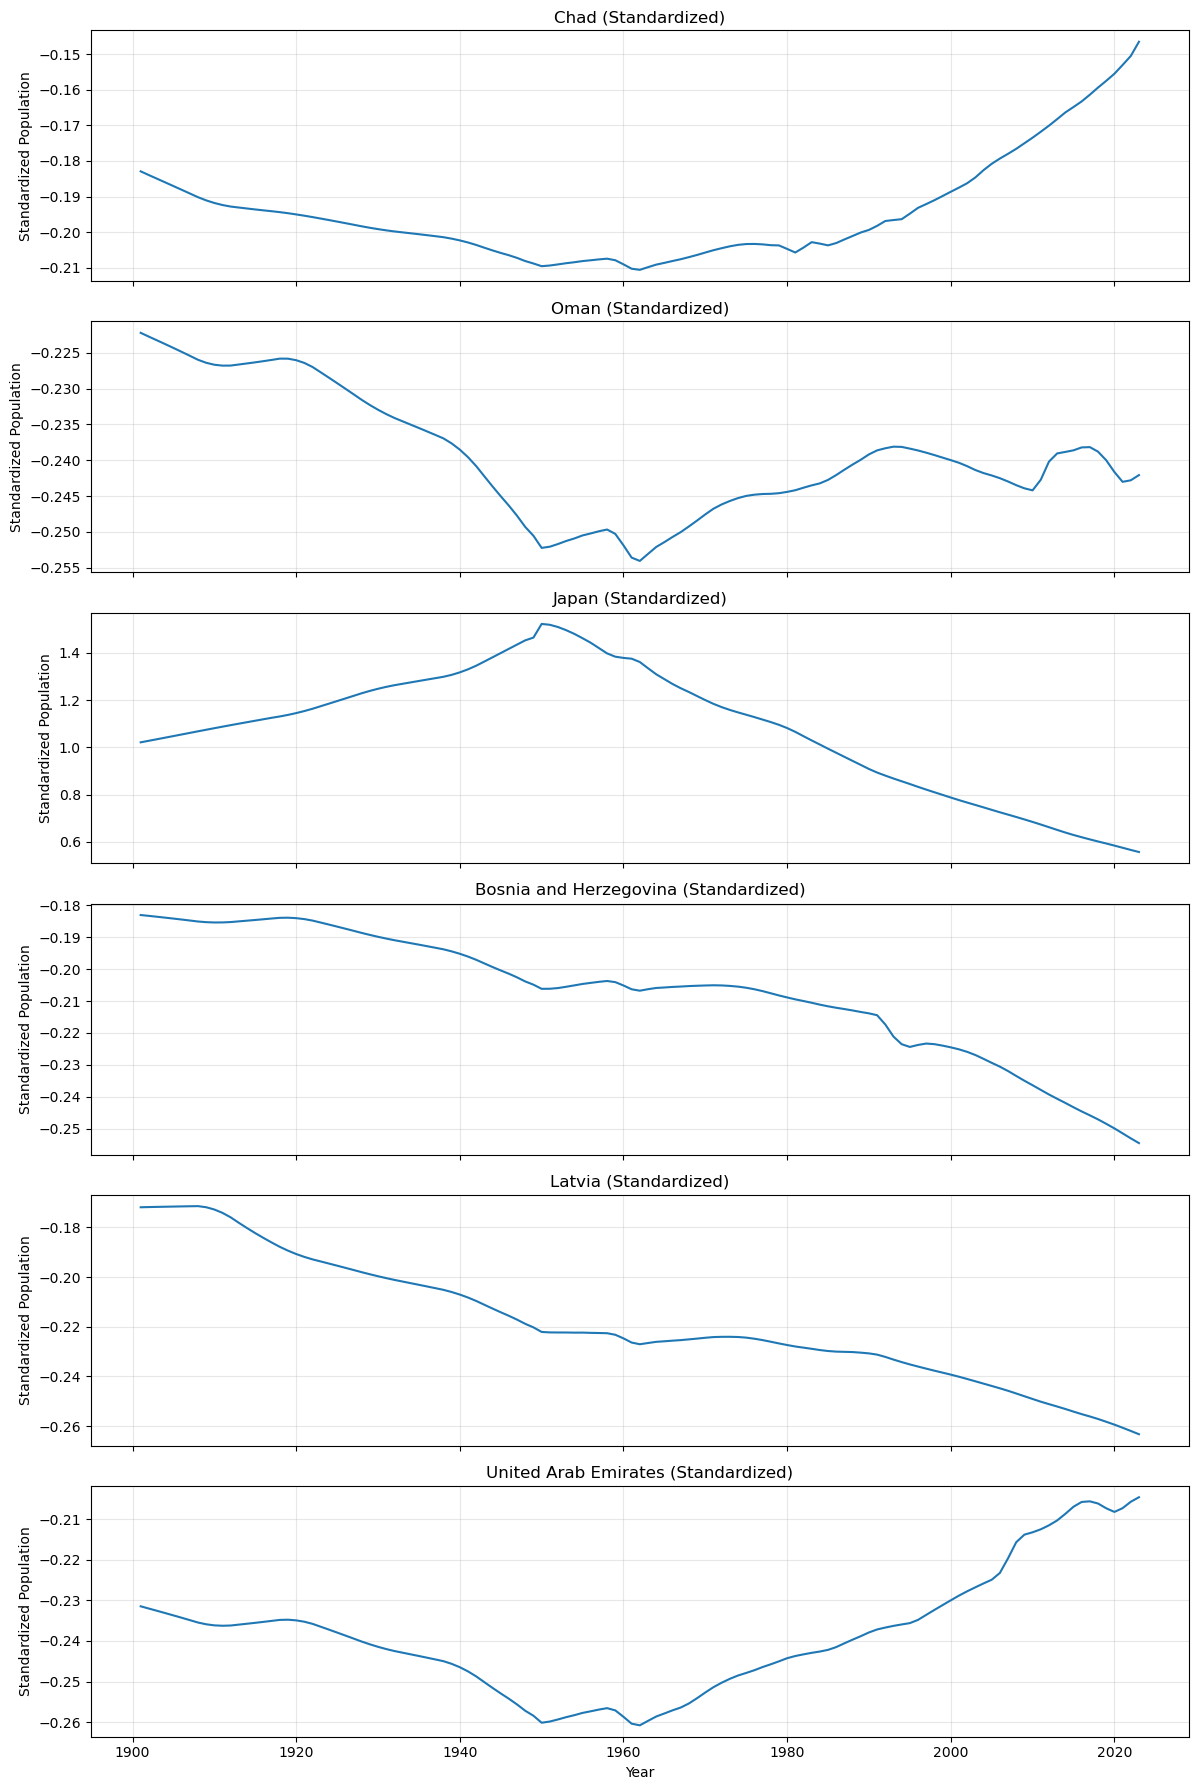

In [4]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import Levenshtein

# 1: function to plot a time-series subplot for each country in input_countries_list
def plot_ts(df, input_countries_list, dataset_type="", ylabel=""):

    n = len(input_countries_list)
    figs, subs = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True)

    for sub, country in zip(subs, input_countries_list):
        sub.plot(df.columns, df.loc[country])
        sub.set_title(f"{country} {dataset_type}".strip())
        sub.set_ylabel(ylabel)
        sub.grid(alpha=0.3)

    subs[-1].set_xlabel("Year")
    plt.tight_layout()
    plt.show()


# 2. standardization using 'StandardScaler'
standardizer = StandardScaler()
sd_population = pd.DataFrame(
    standardizer.fit_transform(population),
    index=population.index,
    columns=population.columns,
)

# year statistics
year_stats = pd.DataFrame({
    "Mean": sd_population.mean(axis=0),
    "Standard Deviation": sd_population.std(axis=0, ddof=0)
})
display(year_stats.round(0))

# 3: two countries whose names are closest to my first name 'EMAD' using 'Levenshtein.distance()'
first_name = "EMAD"
distances = sorted(
    ((Levenshtein.distance(first_name.lower(), c.lower()), c) for c in population.index),
    key=lambda x: x[0],
)

# distance dataframe
distance_df = pd.DataFrame(distances, columns=["Levenshtein Distance", "Country"])
distance_df = distance_df[["Country", "Levenshtein Distance"]]

print("countries ranked by 'Levenshtein Distance' from '%s'" % first_name)
display(distance_df)

closest_two = distance_df.head(2)["Country"].tolist()
print("two closest country names to '%s':" % first_name, closest_two)

# 4: 'plot_ts()' on the original dataset and standardized dataset for [Chad, Oman, Japan, Bosnia and Herzegovina, Latvia, United Arab Emirates]
countries_list_1 = ["Japan", "Bosnia and Herzegovina", "Latvia", "United Arab Emirates"]
countries_list_2 = closest_two + countries_list_1

print("\ncountries input list for 'plot_ts()':", countries_list_2)

# non-standardized time-series
plot_ts(population, countries_list_2, dataset_type="(Non-Standardized)", ylabel="Population")

# standardized time-series
plot_ts(sd_population, countries_list_2, dataset_type="(Standardized)", ylabel="Standardized Population")

## 5. discussion: trends in the standardized time-series

in the standardized time-series, each value shows how far a country's population is from the average population of all countries in that year.

for a particular year:

1. a `positive (+ve)` value means the country's population is higher than the average population of all countries.
2. a `negative (-ve)` value means the country's population is lower than the average population of all countries.
3. a value close to `0` means the country's population is close to the average population of all countries.

#### curve characteristics in the standardized time-series plots:

1. if the standardized curve goes up, it means the country's population is increasing relative to the average population of all countries, even if its absolute population is decreasing.

2. if the standardized curve goes down, it means the country's population is decreasing relative to the average population of all countries, even if its absolute population is increasing.
* in the case of `Japan`: in the non-standardized time-series, its population keeps rising well into the 1950s, but in the standardized time-series, its curve peaks around 1950 and then declines sharply. this shows that although the absolute population of `Japan` was still growing, it was shrinking relative to the rest of the countries in the dataset. it also means that other countries were growing faster than it was.

throughout the entire 123-year range (1901–2023), `Chad`, `Oman`, `Bosnia and Herzegovina`, `Latvia`, and `United Arab Emirates` all have `negative` standardized values, meaning their absolute populations are smaller than the average population of all countries. `Japan`, on the other hand, has `positive` standardized values throughout, meaning its absolute population is consistently above the average population of all countries.

#### individual trends:

`Chad`: the standardized curve decreases until around 1960 and then rises strongly afterward. this means `Chad` was initially falling further behind relative to the average population of all countries, but its population later grew faster relative to many other countries.

`Oman`: the standardized curve drops until around 1960 and then rises afterward. however, it remains negative throughout the period, meaning its population is still below the average population of all countries, even though its absolute population grows significantly.

`Japan`: the standardized values are positive throughout the period, meaning its population is above average. however, after peaking around 1950, the standardized curve declines. this means `Japan` is becoming smaller relative to other countries, even though its absolute population only flattens in recent years.

`Bosnia and Herzegovina`: the standardized values are negative throughout the period and show an almost linear decline. this means its population is below average and is also shrinking relative to the other countries in the dataset.

`Latvia`: the standardized values are negative throughout the period and show an almost linear decline. this means its population is below average and is also shrinking relative to the other countries in the dataset. this is despite its absolute population reaching a peak around 1990.

`United Arab Emirates`: the standardized curve decreases until around 1960 and then rises strongly afterward. however, its absolute population remains almost the same from 1901 to 1960.